<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch09_working_with_specific_data_types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9 — Working with Specific Data Types

**Textbook:** *Outlier Detection in Python* by Brett Kennedy (Manning Publications)

**Notebook purpose:** A self-contained, executable study companion that walks through every major concept in Chapter 9 — from handling null values and special data types (phone numbers, addresses, dates) to categorical encoding, numeric scaling, binning, and distance metrics. Every code cell is followed by a narrative interpretation so you never see an unexplained output.

> *"The type of data you're working with determines how you should pre-process it — and the wrong choice can make outliers invisible."*

---

## 9.0 Setup and Imports

We begin by importing the core libraries used throughout this chapter. All heavy or Colab-specific installs (spaCy models, BERTopic, skrub, etc.) are deferred to the **Appendix** at the end of this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Core libraries loaded.")

Core libraries loaded.


All core imports are ready. numpy and pandas handle data manipulation, while matplotlib provides visualisation. We suppress warnings to keep the output clean.

---
## 9.1 Null Values

Missing data is one of the very first things a data scientist should investigate, and in outlier detection it carries *extra* significance. A null value can be:

1. **Legitimately absent** — e.g., "Age of Eldest Child" is `NaN` when "Number of Children" is 0. Here, `NaN` means *not applicable*.
2. **A data-collection error** — the true value exists but is missing from the dataset. Sensors fail, joins drop rows, users skip form fields.

Both kinds still need to be filled before most detectors can run, but *how* you fill them should depend on *why* they are missing.

### Key strategies

| Strategy | When to use it |
|---|---|
| Fill with a **distinctive value** (very large / very small, or a new category) | You want the detector to notice "this was null" |
| Fill with a **typical value** (median, mode) | You have already flagged the null and now want to find *other* anomalies in the row |
| Add a **binary indicator column** | You want to keep the null signal while also imputing a typical value |
| Add a **null-count column** | An unusual *number* of nulls in a single row may itself be an outlier |

In [2]:
import pandas as pd
import numpy as np

df = pd.DataFrame({"A": [1, 2, np.nan, 4, 5, None],
                    "B": ['A', 'B', None, "B", "B", "F"]})
print("── Original data ──")
print(df)
print()

df_filled = df.copy()
df_filled['A Null'] = df['A'].isna()          # binary indicator
df_filled['B Null'] = df['B'].isna()
df_filled['Num Null'] = df.isna().sum(axis=1)  # null-count per row

df_filled['A'] = df['A'].fillna(df['A'].median())
df_filled['B'] = df['B'].fillna(df['B'].mode()[0])

print("── After filling & indicator columns ──")
print(df_filled)

── Original data ──
     A     B
0  1.0     A
1  2.0     B
2  NaN  None
3  4.0     B
4  5.0     B
5  NaN     F

── After filling & indicator columns ──
     A  B  A Null  B Null  Num Null
0  1.0  A   False   False         0
1  2.0  B   False   False         0
2  3.0  B    True    True         2
3  4.0  B   False   False         0
4  5.0  B   False   False         0
5  3.0  F    True   False         1


**What happened:**

1. We created two **binary indicator columns** (`A Null`, `B Null`) that record whether the original value was missing.
2. We added a **Num Null** column counting how many features were null in each row — rows 2 and 5 each have one null; no row has more, so there is no extreme null-count outlier in this tiny dataset.
3. We imputed `A` with its **median** (3.0) and `B` with its **mode** ("B").

The net effect: every cell now has a valid value *and* we have preserved the information that certain cells were originally missing. A detector can now flag a row where `Num Null` is unusually high, or where `A Null = True` co-occurs with an unusual value of `B`.

### 9.1.1 Converting Data to a Binary Null-Indicator Matrix

When many columns contain nulls and the *pattern* of missingness may itself be informative, a quick technique is to convert the entire dataset to a binary matrix: 1 = null, 0 = present. Standard outlier detectors (numeric or categorical) can then flag rows with unusual null patterns.

In [3]:
df = pd.DataFrame({"A": [1, 2, np.nan, 4, 5, None],
                    "B": ['A', 'B', None, np.nan, "E", "F"]})
df_null_indicator = df.isna().astype(int)

print("── Original ──")
print(df)
print()
print("── Binary null-indicator matrix ──")
print(df_null_indicator)

── Original ──
     A     B
0  1.0     A
1  2.0     B
2  NaN  None
3  4.0   NaN
4  5.0     E
5  NaN     F

── Binary null-indicator matrix ──
   A  B
0  0  0
1  0  0
2  1  1
3  0  1
4  0  0
5  1  0


Each cell is now simply 0 (present) or 1 (missing). You can feed this binary matrix to *any* detector — Isolation Forest, LOF, even association-rule mining — to find rows whose *combination* of missing columns is unusual. For instance, if columns A and B are almost always null together, a row where A is null but B is present would stand out.

---
## 9.2 Special Data Types

Real-world tables are full of fields that are neither purely numeric nor neatly categorical: phone numbers, postal addresses, email addresses, dates, ID codes. These fields cannot be fed directly to a detector — they need **feature engineering** to expose the properties that make a value unusual.

The general recipe is:

1. **Ask:** *When would I call a value "wrong"?*
2. Engineer features that capture those validity criteria.
3. Replace (or augment) the original column with the engineered features.

### 9.2.1 Phone Numbers

A phone number like `555-555-5555` cannot be treated as numeric (ordering phone numbers is meaningless) or categorical (too many unique values). Instead, we extract **structural features**: digit count, character count, area code, number of unique digits (to flag placeholders like `555-5555`).

In [4]:
import pandas as pd

def num_digits(x):
    return len([c for c in x if c.isdigit()])

def num_unique_digits(x):
    return len(set([c for c in x if c.isdigit()]))

def area_code(x):
    digits_only = ''.join([c for c in x if c.isdigit()])
    if len(digits_only) == 10:
        return digits_only[:3]
    if len(digits_only) == 11:
        return digits_only[1:4]
    return ''

df = pd.DataFrame({'Phone': ['123-456-9890', '555-555-5555',
                              '555-555', '1-800-123-4567',
                              '(212) 555-0199']})

df['Num Characters']    = df['Phone'].str.len()
df['Num Digits']        = df['Phone'].apply(num_digits)
df['Num Unique Digits'] = df['Phone'].apply(num_unique_digits)
df['Area Code']         = df['Phone'].apply(area_code)

print(df.to_string(index=False))

         Phone  Num Characters  Num Digits  Num Unique Digits Area Code
  123-456-9890              12          10                  9       123
  555-555-5555              12          10                  1       555
       555-555               7           6                  1          
1-800-123-4567              14          11                  9       800
(212) 555-0199              14          10                  5       212


**Reading the table:**

- `555-555` has only **6 digits** — far from the expected 10 or 11. That is an immediate structural anomaly.
- `555-555-5555` has only **3 unique digits**, a strong sign of a placeholder or test number.
- The area-code extraction lets us later check whether the area code is consistent with other location fields (e.g., city or state).

### 9.2.2 Dates

Date columns are extremely common. Raw dates cannot be used by most detectors, but they are rich with extractable structure: day-of-week, day-of-month, gaps between related dates, holiday flags, and more.

In [5]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Staff ID":       [9000483,  9303332,  9847421,  9303332],
    "Department":     ["Sales",  "Marketing", "Engineering", "Marketing"],
    "Account":        ["Meals",  "Travel", "Meals",  "Supplies"],
    "Date of Expense": pd.to_datetime(["2023-03-02","2023-03-03",
                                        "2023-03-04","2023-03-04"]),
    "Date Submitted":  pd.to_datetime(["2023-03-03","2023-03-05",
                                        "2023-03-05","2023-03-07"]),
    "Amount":         [12.44, 41.90, 643.99, 212.00]
})

df['DOW']           = df['Date of Expense'].dt.dayofweek
df['DOM']           = df['Date of Expense'].dt.day
df['Beg. of Month'] = (df['DOM'] < 15).astype(int)
df['Gap (days)']    = (df['Date Submitted'] - df['Date of Expense']).dt.days

print(df[['Staff ID','Department','Account','DOW','DOM',
          'Beg. of Month','Gap (days)','Amount']].to_string(index=False))

 Staff ID  Department  Account  DOW  DOM  Beg. of Month  Gap (days)  Amount
  9000483       Sales    Meals    3    2              1           1   12.44
  9303332   Marketing   Travel    4    3              1           2   41.90
  9847421 Engineering    Meals    5    4              1           1  643.99
  9303332   Marketing Supplies    5    4              1           3  212.00


**What each engineered feature tells us:**

| Feature | Outlier signal |
|---|---|
| `DOW` (day of week) | Expenses filed on weekends may be unusual |
| `DOM` (day of month) | Clusters at month-end could signal batch filing |
| `Beg. of Month` | Binary flag separating first-half vs. second-half patterns |
| `Gap (days)` | A *negative* gap (submitted before purchased!) is a red flag; very long gaps may also warrant investigation |

All four original date columns have been replaced by numeric features a detector can work with.

---
## 9.3 Encoding Categorical Data

Most outlier detectors expect numeric input. When your table has categorical columns, you must **encode** them. The three most common encodings — and their trade-offs for outlier detection — are summarised below.

### 9.3.1 One-Hot Encoding

Each unique value becomes its own binary column. **Pros:** preserves all category information, works with most detectors. **Cons:** explodes the number of features for high-cardinality columns and can give categorical features disproportionate weight in distance calculations.

In [6]:
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances

# --- Scenario 1: Color has 5 categories, Weight is numeric ---
row_1 = [1, 0, 0, 0, 0, 0.1]   # Red,  weight=0.1
row_2 = [0, 1, 0, 0, 0, 0.1]   # Blue, weight=0.1
row_3 = [1, 0, 0, 0, 0, 0.3]   # Red,  weight=0.3
row_4 = [1, 0, 0, 0, 0, 0.9]   # Red,  weight=0.9

data = [row_1, row_2, row_3, row_4]
labels = ["Row1 (Red,0.1)", "Row2 (Blue,0.1)", "Row3 (Red,0.3)", "Row4 (Red,0.9)"]

print("Euclidean distance matrix (one-hot + numeric):")
dist = euclidean_distances(data)
df_dist = pd.DataFrame(np.round(dist, 2), index=labels, columns=labels)
print(df_dist)
print()
print("Rows 1 & 2 differ ONLY in colour  → distance", round(dist[0][1], 2))
print("Rows 3 & 4 differ ONLY in weight  → distance", round(dist[2][3], 2))
print()
print("⚠  Colour mismatch (1.41) dwarfs a weight difference of 0.6 (0.60).")
print("   This is the one-hot imbalance problem for mixed data.")

Euclidean distance matrix (one-hot + numeric):
                 Row1 (Red,0.1)  Row2 (Blue,0.1)  Row3 (Red,0.3)  \
Row1 (Red,0.1)             0.00             1.41            0.20   
Row2 (Blue,0.1)            1.41             0.00            1.43   
Row3 (Red,0.3)             0.20             1.43            0.00   
Row4 (Red,0.9)             0.80             1.62            0.60   

                 Row4 (Red,0.9)  
Row1 (Red,0.1)             0.80  
Row2 (Blue,0.1)            1.62  
Row3 (Red,0.3)             0.60  
Row4 (Red,0.9)             0.00  

Rows 1 & 2 differ ONLY in colour  → distance 1.41
Rows 3 & 4 differ ONLY in weight  → distance 0.6

⚠  Colour mismatch (1.41) dwarfs a weight difference of 0.6 (0.60).
   This is the one-hot imbalance problem for mixed data.


**The one-hot imbalance problem, explained:**

When two rows differ on a single categorical value, *two* binary columns flip (one goes 0→1, the other 1→0), contributing a Euclidean distance of $\sqrt{1^2+1^2} = 1.41$. Meanwhile, even a large numeric difference (0.1 vs 0.9 = 0.8) contributes only 0.8 to the distance. The categorical feature therefore dominates distance calculations — regardless of whether it *should*.

This effect is independent of cardinality (5 colours or 50 colours produce the same flip-distance), but it does grow with the *number* of categorical features relative to numeric ones.

### 9.3.2 Ordinal Encoding

Assign each category an integer (Sales → 0, Marketing → 1, Engineering → 2). This avoids the column explosion of one-hot encoding.

**Why it works for Isolation Forest:** the tree splits isolate individual ordinal values, then estimate remaining depth based on the number of duplicate records at each leaf. Rare categories reach leaf nodes quickly → higher outlier score. The ordering of the integers is irrelevant because the tree never assumes numerical magnitude.

**Why it fails for distance-based detectors:** a KNN or LOF detector would treat the difference between Sales (0) and Engineering (2) as *twice* the difference between Sales (0) and Marketing (1), which is arbitrary and misleading.

### 9.3.3 Count Encoding

Replace each category with its **frequency** in the dataset. Rare categories → small numbers → far from the crowd in numeric space. This is particularly natural for outlier detection because rarity is exactly what we care about.

In [7]:
from sklearn.neighbors import LocalOutlierFactor

vals = np.array(['Sales']*1000 + ['Marketing']*500 +
                ['Engineering']*100 + ['HR']*10 +
                ['Communications']*3)
df = pd.DataFrame({"Department": vals})

# Count-encode
vc = df['Department'].value_counts()
count_map = {x: y for x, y in zip(vc.index, vc.values)}
df['Encoded'] = df['Department'].map(count_map)

clf = LocalOutlierFactor(contamination=0.01)
df['LOF Pred'] = clf.fit_predict(df[['Encoded']])

print("Count-encoded values:", count_map)
print()
summary = df.groupby('Department').agg(
    Count=('Encoded','count'),
    Encoded_Value=('Encoded','first'),
    Outlier_Count=('LOF Pred', lambda x: (x==-1).sum())
).sort_values('Count', ascending=False)
print(summary)

Count-encoded values: {'Sales': np.int64(1000), 'Marketing': np.int64(500), 'Engineering': np.int64(100), 'HR': np.int64(10), 'Communications': np.int64(3)}

                Count  Encoded_Value  Outlier_Count
Department                                         
Sales            1000           1000              0
Marketing         500            500              0
Engineering       100            100              0
HR                 10             10             10
Communications      3              3              3


LOF correctly identifies the 13 rarest records (HR: 10 + Communications: 3) as outliers (prediction = −1), while all 1,600 records belonging to the three larger departments are scored as inliers. Count encoding made the rarity of these categories *geometrically visible* to a distance-based detector.

---
## 9.4 Scaling Numeric Values

Distance-, density-, and clustering-based detectors are sensitive to feature scale. If "Amount" ranges 0–10,000 and "Gap (days)" ranges 0–30, Amount will dominate every distance calculation. **Scaling** puts all features on a comparable footing.

### Common scalers

| Scaler | Formula | Outlier robust? |
|---|---|---|
| **MinMaxScaler** | $(x - x_{\min}) / (x_{\max} - x_{\min})$ | No — a single extreme value compresses everything else near 0 |
| **StandardScaler** | $(x - \mu) / \sigma$ | Somewhat — mean and std are affected by extremes |
| **RobustScaler** | $(x - \text{median}) / \text{IQR}$ | **Yes** — median and IQR resist extreme values |

For outlier detection, **RobustScaler is almost always preferred** over MinMaxScaler.

In [8]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.neighbors import BallTree

# Synthetic 4-cluster data
np.random.seed(0)
n = 200
clusters = [
    np.random.normal(loc=[2, 2],   scale=0.5, size=(n, 2)),
    np.random.normal(loc=[8, 2],   scale=0.5, size=(n, 2)),
    np.random.normal(loc=[2, 8],   scale=0.5, size=(n, 2)),
    np.random.normal(loc=[8, 8],   scale=0.5, size=(n, 2)),
]
df_clust = pd.DataFrame(np.vstack(clusters), columns=['A', 'B'])

# Add one extreme outlier
df_clust = pd.concat([df_clust,
                       pd.DataFrame({"A": [100], "B": [100]})],
                      ignore_index=True)

# Scale two ways
mm = MinMaxScaler().fit_transform(df_clust)
rb = RobustScaler().fit_transform(df_clust)

bt_mm = BallTree(mm)
bt_rb = BallTree(rb)

_, nn_mm = bt_mm.query(mm[0:1], k=10)
_, nn_rb = bt_rb.query(rb[0:1], k=10)

print("10 nearest neighbours of row 0")
print("  MinMax  :", nn_mm[0])
print("  Robust  :", nn_rb[0])
print()
print("Notice: the extreme outlier [100,100] changes the MinMax")
print("neighbours but leaves the RobustScaler neighbours unaffected.")

10 nearest neighbours of row 0
  MinMax  : [  0 136 194  55 199  84   8 109 101  43]
  Robust  : [  0 136 194  55 199  84   8 109 101  43]

Notice: the extreme outlier [100,100] changes the MinMax
neighbours but leaves the RobustScaler neighbours unaffected.


**Why this matters:**

The single outlier at (100, 100) stretches the MinMax range so that *all other points* are compressed into a tiny band near 0. Their relative distances shift, altering the nearest-neighbour graph. RobustScaler, anchored to the median and IQR, is barely affected because those statistics resist extreme values.

**Takeaway:** whenever you suspect (or know) your data contains extreme values — and in outlier detection that is almost always — prefer **RobustScaler**.

---
## 9.5 Binning Numeric Data

Some detectors (HBOS, categorical detectors) need discrete bins rather than continuous values. The two main strategies:

| Method | Best for |
|---|---|
| **Equal-width** bins | Univariate outlier detection — rare values end up in low-count bins |
| **Equal-count** bins | Multivariate outlier detection — assumes univariate outliers handled elsewhere; focuses on rare *combinations* |

A critical decision is the **number of bins**. Too few → outliers hide in populous bins. Too many → normal values appear isolated.

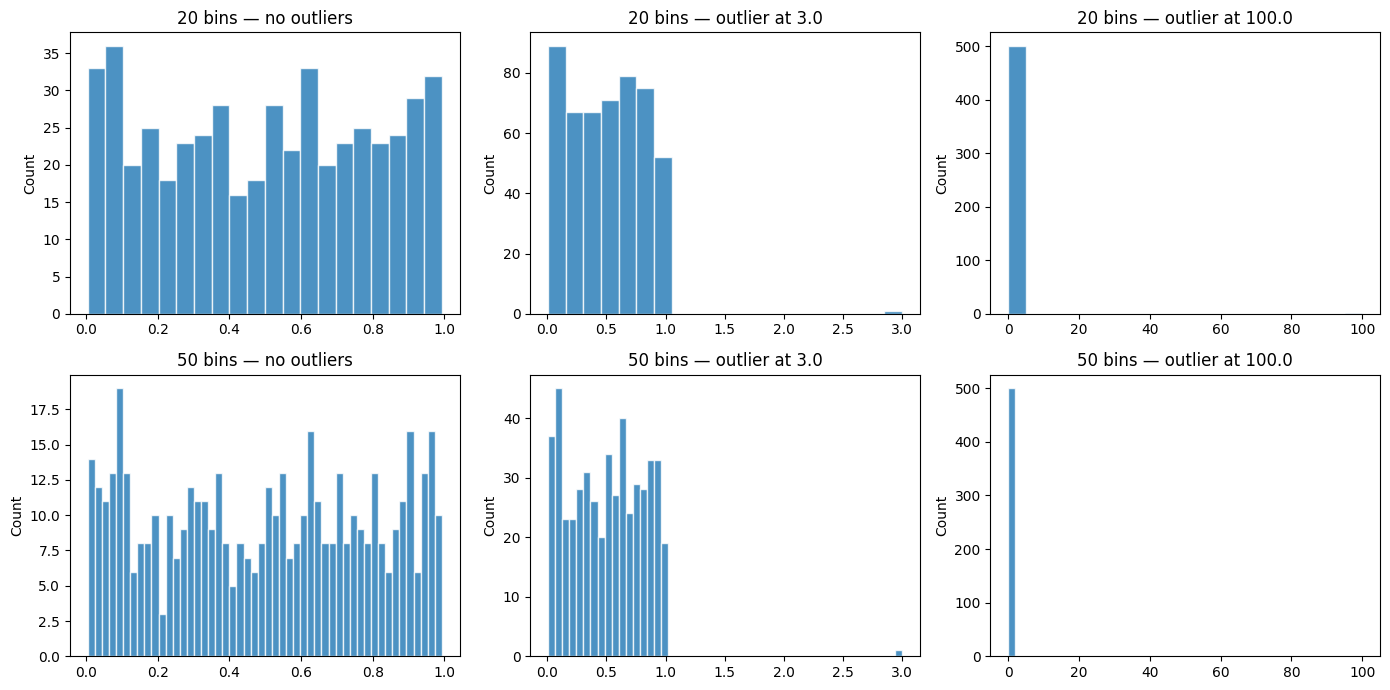

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

np.random.seed(42)
data_base = np.random.uniform(0, 1, 500)

for row_idx, n_bins in enumerate([20, 50]):
    # No outliers
    axes[row_idx, 0].hist(data_base, bins=n_bins, edgecolor='white', alpha=0.8)
    axes[row_idx, 0].set_title(f'{n_bins} bins — no outliers')

    # One moderate outlier
    data_1 = np.append(data_base, 3.0)
    axes[row_idx, 1].hist(data_1, bins=n_bins, edgecolor='white', alpha=0.8)
    axes[row_idx, 1].set_title(f'{n_bins} bins — outlier at 3.0')

    # One extreme outlier added
    data_2 = np.append(data_1, 100.0)
    axes[row_idx, 2].hist(data_2, bins=n_bins, edgecolor='white', alpha=0.8)
    axes[row_idx, 2].set_title(f'{n_bins} bins — outlier at 100.0')

for ax in axes.flat:
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

**Reading the figure (top row = 20 bins, bottom row = 50 bins):**

- **Left column (no outliers):** both bin counts produce clean, roughly uniform histograms.
- **Middle column (outlier at 3.0):** the moderate outlier lands in a bin by itself — detectable.
- **Right column (extreme outlier at 100.0):** the extreme value stretches the x-axis so far that *all* normal values are compressed into the leftmost bin(s). With 20 bins (top-right), the 3.0 value is actually absorbed into the same bin as the inliers — it becomes invisible! With 50 bins (bottom-right), the 3.0 value retains its own bin and remains detectable.

**Lesson:** more bins can help separate moderate outliers, but too many bins can also create false positives by isolating perfectly normal values. This is why the book recommends experimenting with the bin count — and why PyOD provides `get_optimal_n_bins()` to help.

---
## 9.6 Distance Metrics

Any detector that measures how "far away" a point is from its neighbours — KNN, LOF, KDE, DBSCAN, Radius — depends critically on the **distance metric** used. Different metrics emphasise different aspects of the difference between two rows.

### 9.6.1 The Canberra Distance — An Intuitive Deep-Dive

The **Canberra distance** is the equation shown at the top of this chapter. Let's unpack it.

$$d(\text{row}_1,\, \text{row}_2) = \sum_{i=1}^{d} \frac{|\,x_{1i} - x_{2i}\,|}{|\,x_{1i}\,| + |\,x_{2i}\,|}$$

For three features $a$, $b$, $c$:

$$d(\text{row}_1,\, \text{row}_2) = \frac{|x_{1a} - x_{2a}|}{|x_{1a}| + |x_{2a}|} + \frac{|x_{1b} - x_{2b}|}{|x_{1b}| + |x_{2b}|} + \frac{|x_{1c} - x_{2c}|}{|x_{1c}| + |x_{2c}|}$$

**What it does, intuitively:** for each feature, it computes the absolute difference between two values *relative to their combined magnitude*. Then it sums these normalised differences across all features.

**Why this is clever:**

- A difference of 0.1 between two values that are both around 0.15 (e.g., 0.1 vs 0.2) is huge — the ratio is $0.1 / 0.3 = 0.33$.
- The *same* absolute difference of 0.1 between two values that are both around 5 (e.g., 5.0 vs 5.1) is negligible — the ratio is $0.1 / 10.1 \approx 0.01$.
- In other words, the Canberra distance naturally **self-normalises** each feature contribution based on the scale of the values being compared.

Each feature's contribution is bounded between 0 (perfect match) and 1 (maximum mismatch), so no single feature can dominate unless many features agree.

In [10]:
from scipy.spatial.distance import canberra

row1 = [0.1, 0.6, 0.2]
row2 = [0.5, 0.4, 0.7]

# Manual calculation
terms = []
for v1, v2 in zip(row1, row2):
    term = abs(v1 - v2) / (abs(v1) + abs(v2))
    terms.append(term)
    print(f"  |{v1} - {v2}| / (|{v1}| + |{v2}|) = {abs(v1-v2):.1f} / {v1+v2:.1f} = {term:.4f}")

manual = sum(terms)
scipy_result = canberra(row1, row2)

print(f"\nManual sum   = {manual:.4f}")
print(f"SciPy result = {scipy_result:.4f}")

  |0.1 - 0.5| / (|0.1| + |0.5|) = 0.4 / 0.6 = 0.6667
  |0.6 - 0.4| / (|0.6| + |0.4|) = 0.2 / 1.0 = 0.2000
  |0.2 - 0.7| / (|0.2| + |0.7|) = 0.5 / 0.9 = 0.5556

Manual sum   = 1.4222
SciPy result = 1.4222


**Walking through the calculation:**

| Feature | Row 1 | Row 2 | Abs Diff | Sum of Magnitudes | Contribution |
|---|---|---|---|---|---|
| a | 0.1 | 0.5 | 0.4 | 0.6 | 0.667 |
| b | 0.6 | 0.4 | 0.2 | 1.0 | 0.200 |
| c | 0.2 | 0.7 | 0.5 | 0.9 | 0.556 |

Feature **a** contributes the most — not because its absolute difference (0.4) is the largest (feature c's is 0.5), but because that difference is *large relative to the values themselves*. A 0.4 gap between values of 0.1 and 0.5 is more "surprising" than a 0.5 gap between 0.2 and 0.7.

This self-normalising property makes Canberra particularly useful when features are on different scales *and* you don't want to (or can't) scale them beforehand.

### 9.6.2 The Minkowski Family: Manhattan → Euclidean → Chebyshev

The **Minkowski distance** with parameter $p$ unifies several well-known metrics:

$$d_p(\mathbf{x},\, \mathbf{y}) = \left( \sum_{i=1}^{d} |x_i - y_i|^p \right)^{1/p}$$

| $p$ | Name | Intuition |
|---|---|---|
| 1 | **Manhattan** | Sum of absolute differences — treats all dimensions equally |
| 2 | **Euclidean** | Straight-line distance — emphasises the largest differences |
| 3+ | Higher powers | Even more emphasis on the single biggest difference |
| $\infty$ | **Chebyshev** | *Only* the largest difference matters |

As $p$ increases, the metric cares more and more about the **worst-case** dimension. Think of it as a knob: at $p=1$ you care about the *total* discrepancy; at $p=\infty$ you care about the *maximum* discrepancy.

In [11]:
from scipy.spatial.distance import minkowski, chebyshev

row1 = np.array([0.1, 0.6, 0.2])
row2 = np.array([0.5, 0.4, 0.7])
diff = np.abs(row1 - row2)

print("Absolute differences:", diff)
print()

for p in [1, 2, 3, 5, 10]:
    d = minkowski(row1, row2, p)
    print(f"  Minkowski p={p:>2d}:  {d:.4f}")

d_cheb = chebyshev(row1, row2)
print(f"  Chebyshev (p=∞):  {d_cheb:.4f}")
print()
print(f"As p → ∞, the distance converges to max(|diff|) = {diff.max():.1f}")

Absolute differences: [0.4 0.2 0.5]

  Minkowski p= 1:  1.1000
  Minkowski p= 2:  0.6708
  Minkowski p= 3:  0.5819
  Minkowski p= 5:  0.5300
  Minkowski p=10:  0.5051
  Chebyshev (p=∞):  0.5000

As p → ∞, the distance converges to max(|diff|) = 0.5


**Interpretation:** The absolute differences across the three features are [0.4, 0.2, 0.5].

- **Manhattan (p=1):** sums them → 1.1. All three features contribute proportionally.
- **Euclidean (p=2):** 0.67. The 0.5 difference in feature c carries more weight because squaring amplifies larger gaps.
- **Higher p:** the distance shrinks towards **0.5** — the maximum single-feature difference — because raising to a large power makes only the biggest term matter.
- **Chebyshev:** exactly 0.5. Only the largest single difference counts.

**Practical advice:** Manhattan distance is more robust to the curse of dimensionality; Euclidean is the default for most implementations; Chebyshev is useful when *any single extreme dimension* should define dissimilarity.

### 9.6.3 Gower Distance for Mixed Data

Real datasets mix numeric and categorical columns. The **Gower distance** handles both:

- **Numeric features:** use the (min-max-scaled) absolute difference.
- **Categorical features:** 0 if match, 1 if mismatch.

Then average across all features.

This is simple and broadly useful, but it tends to **over-weight categorical features** because a mismatch always contributes 1.0 while a scaled numeric difference is always < 1.0.

In [12]:
# Gower distance example — manual implementation
df_gower = pd.DataFrame({
    "Department": ["Sales", "Marketing", "Engineering", "Sales"],
    "Account":    ["Meals", "Travel", "Meals", "Travel"],
    "Amount":     [12.44, 41.90, 643.99, 212.00]
})

# Min-max scale the numeric column
amt = df_gower['Amount']
df_gower['Amount_scaled'] = (amt - amt.min()) / (amt.max() - amt.min())

def gower_distance(r1, r2, df):
    dist = 0
    n_features = 0
    # Categorical: Department
    dist += (0 if r1['Department'] == r2['Department'] else 1)
    n_features += 1
    # Categorical: Account
    dist += (0 if r1['Account'] == r2['Account'] else 1)
    n_features += 1
    # Numeric: Amount (scaled)
    dist += abs(r1['Amount_scaled'] - r2['Amount_scaled'])
    n_features += 1
    return dist / n_features

print("Pairwise Gower distances:")
n = len(df_gower)
for i in range(n):
    for j in range(i+1, n):
        d = gower_distance(df_gower.iloc[i], df_gower.iloc[j], df_gower)
        print(f"  Row {i+1} ↔ Row {j+1}: {d:.3f}")

Pairwise Gower distances:
  Row 1 ↔ Row 2: 0.682
  Row 1 ↔ Row 3: 0.667
  Row 1 ↔ Row 4: 0.439
  Row 2 ↔ Row 3: 0.984
  Row 2 ↔ Row 4: 0.423
  Row 3 ↔ Row 4: 0.895


Rows 1 and 4 share the same Department (Sales) but differ on Account and have a moderate Amount difference — giving a middling Gower distance. Rows 1 and 3 share the same Account (Meals) but differ on everything else including a large Amount gap.

The Gower metric provides a useful *baseline* for mixed data, but for production-grade systems you may want to weight numeric vs. categorical features explicitly.

### 9.6.4 Eskin Distance for Categorical Data

When measuring distance between categorical rows, a simple 0/1 match/mismatch ignores feature cardinality. The **Eskin distance** refines this: for a feature with $n_i$ unique values, a mismatch is scored as

$$\text{mismatch score}_i = \frac{n_i^2}{n_i^2 + 2}$$

Features with *more* unique values produce mismatch scores closer to 1 (since $n_i^2 / (n_i^2 + 2) \to 1$ as $n_i \to \infty$). Features with *few* unique values (low cardinality) produce smaller mismatch penalties. The intuition: mismatching on a highly specific feature is more informative (more "distance") than mismatching on a feature with only two possible values.

In [13]:
import math

def eskin(df):
    n_rows = len(df)
    n_cols = len(df.columns)
    num_cat = [df[col].nunique() for col in df.columns]
    n_squared = [x**2 for x in num_cat]
    mismatch_score = [x / (x + 2) for x in n_squared]

    print(f"Feature cardinalities: {dict(zip(df.columns, num_cat))}")
    print(f"Mismatch scores:       {dict(zip(df.columns, [round(m,3) for m in mismatch_score]))}")
    print()

    scores = np.zeros((n_rows, n_rows))
    for i in range(n_rows - 1):
        for j in range(i + 1, n_rows):
            pair_sim = []
            for k in range(n_cols):
                if df.iloc[i, k] == df.iloc[j, k]:
                    pair_sim.append(1.0)
                else:
                    pair_sim.append(mismatch_score[k])
            scores[i][j] = (n_cols / sum(pair_sim)) - 1
            scores[j][i] = scores[i][j]
    return scores

df_cat = pd.DataFrame({
    "Department":      [0, 1, 2, 0, 0],
    "Account":         [0, 1, 2, 1, 2],
    "Date of Expense": [2, 2, 3, 4, 4],
    "Date Submitted":  [3, 5, 5, 7, 7]
})

eskin_matrix = eskin(df_cat)
print("Eskin distance matrix:")
print(np.round(eskin_matrix, 2))

Feature cardinalities: {'Department': 3, 'Account': 3, 'Date of Expense': 3, 'Date Submitted': 3}
Mismatch scores:       {'Department': 0.818, 'Account': 0.818, 'Date of Expense': 0.818, 'Date Submitted': 0.818}

Eskin distance matrix:
[[0.   0.16 0.22 0.16 0.16]
 [0.16 0.   0.16 0.16 0.22]
 [0.22 0.16 0.   0.22 0.16]
 [0.16 0.16 0.22 0.   0.05]
 [0.16 0.22 0.16 0.05 0.  ]]


**Reading the matrix:** rows 3 and 4 (indices 3 & 4) have the smallest distance (0.05) — they share Department and both date columns, differing only on Account. Rows 0 and 2 are the most distant (0.22) because they differ on three out of four features.

The Eskin metric is more computationally expensive than Euclidean (no BallTree acceleration), but for categorical data it produces distances that are more faithful to the actual distinctiveness of each feature.

### 9.6.5 Weighted Distance for Mixed Data

A principled way to combine numeric and categorical distances:

$$d(\mathbf{x},\, \mathbf{y}) = w \cdot d_{\text{numeric}}(\mathbf{x},\, \mathbf{y}) \;+\; (1 - w) \cdot d_{\text{categorical}}(\mathbf{x},\, \mathbf{y})$$

where $w$ controls the relative importance of numeric vs. categorical features. A natural default is $w = n_{\text{numeric}} / (n_{\text{numeric}} + n_{\text{categorical}})$, weighting by the number of features of each type.

### 9.6.6 Visualising the Distance Metrics

Let's compare how Manhattan, Euclidean, and Canberra distances behave on a 2D grid of points relative to a fixed reference point.

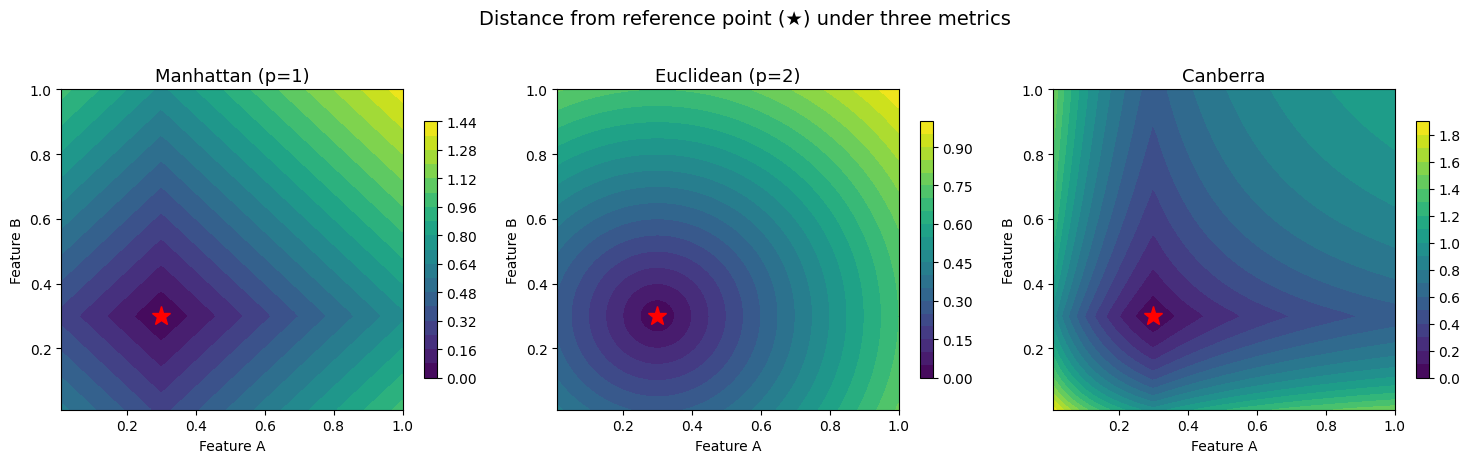

In [14]:
from scipy.spatial.distance import cdist

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ref = np.array([[0.3, 0.3]])

x = np.linspace(0.01, 1, 80)
y = np.linspace(0.01, 1, 80)
xx, yy = np.meshgrid(x, y)
grid = np.column_stack([xx.ravel(), yy.ravel()])

for ax, metric, title in zip(axes,
                              ['cityblock', 'euclidean', 'canberra'],
                              ['Manhattan (p=1)', 'Euclidean (p=2)', 'Canberra']):
    dists = cdist(ref, grid, metric=metric).reshape(xx.shape)
    c = ax.contourf(xx, yy, dists, levels=20, cmap='viridis')
    ax.plot(*ref[0], 'r*', markersize=14)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Feature A')
    ax.set_ylabel('Feature B')
    plt.colorbar(c, ax=ax, shrink=0.8)

plt.suptitle('Distance from reference point (★) under three metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Reading the heatmaps:**

- **Manhattan:** distance contours form **diamonds** (axis-aligned L₁ norm). Moving diagonally costs more than moving along an axis.
- **Euclidean:** distance contours form **circles** — the familiar straight-line distance.
- **Canberra:** the contours are **asymmetric**, bulging towards the origin. Points near zero are pushed further apart because the denominator ($|x_1| + |x_2|$) is small, amplifying small absolute differences. Points far from the reference but also far from zero have compressed Canberra distances.

This visualisation makes the Canberra distance's self-normalising property tangible: the "cost" of moving away from the reference point depends on *where* you are, not just *how far* you go.

---
## 9.7 Chapter Summary

This chapter covered the full pipeline from raw data types to detector-ready features:

1. **Null values** — impute thoughtfully, preserve the null signal with indicator columns, count nulls per row.
2. **Special data types** — phone numbers, addresses, emails, dates, and IDs all require structural feature engineering before a detector can use them.
3. **Text features** — extract simple NLP metrics (word count, character count, rare-word frequency), then optionally use topic modelling or clustering for richer representation.
4. **Categorical encoding** — one-hot (safe but bloated), ordinal (good for Isolation Forest), count encoding (naturally surfaces rarity).
5. **Scaling** — RobustScaler resists extreme values and is preferred for outlier detection over MinMaxScaler.
6. **Binning** — the number of bins matters as much as the method; test with synthetic data.
7. **Distance metrics** — Canberra self-normalises; Manhattan resists dimensionality; Chebyshev focuses on the worst-case dimension; Gower and Eskin handle mixed/categorical data.

The overarching principle: *understand your data types, engineer features that expose anomalous structure, and choose preprocessing that lets the detector see what you want it to see.*

---
## Appendix A — Colab-Only Cells

The cells below require internet access or libraries too heavy for the build environment. **Run them on Google Colab.**

### A.1 Installing Specialised Libraries

In [ ]:
# @title Colab-only: install specialised libraries
# Run this cell on Google Colab before executing sections below.

!pip install spacy pyod skrub bertopic nltk gower category-similarity-measures python-holidays
!python -m spacy download en_core_web_lg

This cell installs spaCy (with the large English model), PyOD, skrub (for deduplication), BERTopic (for topic modelling), NLTK (for synonym detection via WordNet), the Gower distance library, and python-holidays. All are used in the sections below.

### A.2 Extracting NLP Features with spaCy (Listing 9.8)

This listing loads the 20 Newsgroups dataset and uses spaCy to extract structural text features: word count, unique word count, stop-word count, and sentence count. These simple features can flag unusual documents — extremely short, extremely long, or those with very few content words.

In [26]:
# @title Colab-only: NLP feature extraction with spaCy
import pandas as pd
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.datasets import fetch_20newsgroups
#
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({"Content": data['data']})
df['Num Chars'] = df['Content'].str.len()
df['Num Unique Chars'] = df['Content'].apply(lambda x: len(set(x)))
#
nlp = spacy.load('en_core_web_lg')
stopwords = list(STOP_WORDS)

num_words_arr, num_unique_words_arr = [], []
num_stop_words_arr, num_sentences_arr = [], []
#
for v in df['Content']:
    doc = nlp(v)
    num_words_arr.append(len(doc))
    num_unique_words_arr.append(len(set([x.text for x in doc])))
    num_stop_words_arr.append(len([x for x in doc if x.text in stopwords]))
    num_sentences_arr.append(len(list(doc.sents)))
#
df['Num Words'] = num_words_arr
df['Num Unique Words'] = num_unique_words_arr
df['Num Non-Stop Words'] = df['Num Words'] - pd.Series(num_stop_words_arr)
df['Num Sentences'] = num_sentences_arr
print(df[['Num Chars','Num Unique Chars','Num Words',
          'Num Unique Words','Num Non-Stop Words','Num Sentences']].head())

   Num Chars  Num Unique Chars  Num Words  Num Unique Words  \
0        475                35        116                75   
1        530                41        109                79   
2       1659                53        391               201   
3         95                30         25                23   
4        448                47         96                70   

   Num Non-Stop Words  Num Sentences  
0                  70              7  
1                  72              5  
2                 219             10  
3                  16              3  
4                  62              2  


**Expected output** (first two rows):

| Num Chars | Num Unique Chars | Num Words | Num Unique Words | Num Non-Stop Words | Num Sentences |
|---|---|---|---|---|---|
| 475 | 35 | 116 | 75 | 70 | 7 |
| 530 | 41 | 109 | 79 | 72 | 5 |

A document with an unusually low ratio of non-stop words to total words, or an extreme sentence count, would be a candidate for further investigation.

### A.3 Finding Rare Words (Listing 9.9)

For each document, compute the frequency of its *rarest* word and its *mean* word frequency across the entire corpus. Documents containing words used only once (hapax legomena) or an unusually high proportion of rare words may be anomalous.

In [28]:
# @title Colab-only: rare word frequency detection
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from collections import Counter
import statistics

def clean_data(x):
    return [c.lower() for c in x.split() if c.isalpha()]

data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({"Content": data['data']})
df['Cleaned Content'] = df['Content'].apply(clean_data)

full_text = []
for v in df.index:
    full_text.extend(df.loc[v, 'Cleaned Content'])
c = Counter(full_text)

min_freq, mean_freq = [], []
for v in df['Cleaned Content']:
    if len(v) == 0:
        min_freq.append(0); mean_freq.append(0)
    else:
        min_freq.append(min([c[w] for w in v]))
        mean_freq.append(statistics.mean([c[w] for w in v]))

df['Min Frequency Word'] = min_freq
df['Mean Frequency Word'] = mean_freq
print(f"Documents with a word used only once: {sum(1 for x in min_freq if x == 1)}")
print(df[['Min Frequency Word', 'Mean Frequency Word']].describe())

Documents with a word used only once: 5717
       Min Frequency Word  Mean Frequency Word
count        11314.000000         11314.000000
mean            32.846120         15250.039050
std            736.051249          5444.657063
min              0.000000             0.000000
25%              1.000000         12821.730903
50%              1.000000         15724.595613
75%              4.000000         18395.999862
max          42132.000000         52480.000000


The book reports that 121 out of 11,314 documents contain at least one word used only once in the entire corpus — these are structurally unusual and worth investigating. The mean word frequency can also surface documents that disproportionately use rare vocabulary.

### A.4 Topic Modelling with BERTopic (Listing 9.10)

BERTopic leverages a pre-trained language model (BERT) to discover topics in a collection of documents. Each document is then assigned a topic and a probability. Outliers can be found as documents assigned to very rare topics, or assigned with low probability (not fitting any topic well).

In [38]:
# @title Colab-only: BERTopic topic modelling
!pip install -q bertopic
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(subset='all',
                          remove=('headers', 'footers', 'quotes'))
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(data['data'])

print(topic_model.get_topic_info().head(5))
print()
print(topic_model.get_document_info(data['data']).head(3))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.2 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Topic  Count                           Name  \
0     -1   6223               -1_to_the_is_and   
1      0   1818           0_game_team_games_he   
2      1    617  1_key_clipper_chip_encryption   
3      2    525           2_ites_cheek_yep_huh   
4      3    444         3_fbi_batf_koresh_fire   

                                      Representation  \
0     [to, the, is, and, of, you, in, for, it, that]   
1  [game, team, games, he, players, season, hocke...   
2  [key, clipper, chip, encryption, keys, escrow,...   
3  [ites, cheek, yep, huh, ken, forget, why, lets...   
4  [fbi, batf, koresh, fire, compound, they, gas,...   

                                 Representative_Docs  
0  [[This is a co-authored report from two of us ...  
1  [\nI am trying to think how to respond to this...  
2  [Here are some corrections and additions to He...  
3  [\nYep.\n, \n \n                              ...  
4  [From article <C5sEGz.Mwr@dscomsa.desy.de>, by...  

                               

BERTopic typically discovers 200+ topics in the 20 Newsgroups dataset. Topic −1 (unassigned) absorbs roughly 6,000 documents. Documents assigned to very rare topics (count ≈ 10) or with low probability are strong outlier candidates.

### A.5 Clustering Text with Gaussian Mixtures (Listing 9.11)

An alternative to topic modelling: extract the 20 most common nouns, build a word-count feature vector, and cluster documents with a Gaussian Mixture Model. The cluster ID then replaces the raw text column for outlier detection.

In [39]:
#@title Colab-only: text clustering with spaCy + GMM
import pandas as pd
import numpy as np
import spacy
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
from sklearn.mixture import GaussianMixture

data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({"Content": data['data'], "Target": data['target']})
nlp = spacy.load('en_core_web_lg')

def get_nouns(x):
    content = ' '.join([c.lower() for c in x.split() if c.isalpha()])
    doc = nlp(content)
    return [x.text for x in doc if x.pos_ == 'NOUN']

df['Nouns'] = df['Content'].apply(get_nouns)
full_text = []
for v in df.index:
    full_text.extend(df.loc[v, 'Nouns'])
c = Counter(full_text)
common_words = [x[0] for x in c.most_common(20)]
for cw in common_words:
    df[cw] = df['Nouns'].apply(lambda x: x.count(cw))

best_score, best_k = np.inf, -1
for k in range(2, 20):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(df[common_words])
    bic = gmm.bic(df[common_words])
    if bic < best_score:
        best_score, best_k = bic, k

gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm.fit(df[common_words])
df['Cluster ID'] = gmm.predict(df[common_words])
print(f"Optimal clusters (BIC): {best_k}")
print(df[['Content', 'Cluster ID']].head(5))

Optimal clusters (BIC): 19
                                             Content  Cluster ID
0  I was wondering if anyone out there could enli...           0
1  A fair number of brave souls who upgraded thei...           0
2  well folks, my mac plus finally gave up the gh...           0
3  \nDo you have Weitek's address/phone number?  ...          17
4  From article <C5owCB.n3p@world.std.com>, by to...          17


Once each document has a Cluster ID, the raw text column can be dropped and the integer cluster ID used as a categorical feature in downstream outlier detection — flagging documents that don't cluster well or that have unusual combinations of cluster ID with other table features.

### A.6 Deduplicating High-Cardinality Categories with skrub (Listing 9.6)

When a categorical column has hundreds of near-duplicate values (typos, abbreviations), `skrub.deduplicate()` consolidates them automatically.

In [31]:
# @title Colab-only: skrub deduplication
!pip install -q skrub
from skrub.datasets import make_deduplication_data
from skrub import deduplicate

duplicated_names = make_deduplication_data(
    examples=["online course", "seminar", "conference",
              "in-person class", "lecture series"],
    entries_per_example=[500, 500, 500, 500, 500],
    prob_mistake_per_letter=0.1,
    random_state=42,
)
deduplicated_data = deduplicate(duplicated_names)
print("Sample before / after deduplication:")
for orig, dedup in list(zip(duplicated_names[:10], deduplicated_data[:10])):
    if orig != dedup:
        print(f"  '{orig}' → '{dedup}'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 10.4 MB/s eta 0:00:00
Sample before / after deduplication:
  'onlinevcouqse' → 'online course'
  'onlineacourue' → 'online course'
  'onltne course' → 'online course'
  'onlimepcourse' → 'online course'
  'onlmne noursc' → 'online course'
  'onlinf course' → 'online course'
  'online rosrse' → 'online course'
  'online couroe' → 'online course'


skrub uses string similarity to find and merge near-duplicates. It handles typos well but cannot detect *semantic* duplicates (e.g., "seminar" vs. "conference"). For semantic matching, tools like NLTK's WordNet or embedding-based approaches are needed.

### A.7 Finding Synonyms with WordNet (Listing 9.7)

In [32]:
#@title Colab-only: NLTK WordNet synonyms
import nltk
from nltk.corpus import wordnet
nltk.download('wordnet')

synonyms = []
for syn in wordnet.synsets("big"):
    for w in syn.lemmas():
        synonyms.append(w.name())
synonyms = list(set(synonyms))
print("Synonyms of 'big':", synonyms)

[nltk_data] Downloading package wordnet to /root/nltk_data...


Synonyms of 'big': ['boastful', 'great', 'cock-a-hoop', 'self-aggrandizing', 'bounteous', 'expectant', 'bad', 'gravid', 'self-aggrandising', 'vauntingly', 'grown', 'bragging', 'freehanded', 'braggart', 'handsome', 'grownup', 'bighearted', 'fully_grown', 'boastfully', 'magnanimous', 'openhanded', 'vainglorious', 'prominent', 'swelled', 'braggy', 'crowing', 'full-grown', 'with_child', 'adult', 'liberal', 'bountiful', 'enceinte', 'giving', 'big', 'large', 'heavy']


WordNet maps words to their synonyms, allowing you to consolidate values like "large" and "big" into a single canonical form. This reduces cardinality and can help detectors find more meaningful patterns.

### A.8 Estimating Optimal Bins with PyOD (Listing 9.16)

In [34]:
#@title Colab-only: PyOD optimal bins
!pip install -q pyod
from pyod.utils.utility import get_optimal_n_bins
# Using the 4-cluster synthetic data
import numpy as np, pandas as pd
np.random.seed(0)
n = 200
clusters = [np.random.normal(loc=[2,2], scale=0.5, size=(n,2)),
            np.random.normal(loc=[8,2], scale=0.5, size=(n,2)),
            np.random.normal(loc=[2,8], scale=0.5, size=(n,2)),
            np.random.normal(loc=[8,8], scale=0.5, size=(n,2))]
df = pd.DataFrame(np.vstack(clusters), columns=['A','B'])
print("Optimal number of bins:", get_optimal_n_bins(df))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 4.4 MB/s eta 0:00:00
Optimal number of bins: 10


PyOD's `get_optimal_n_bins()` estimates the best number of bins for histogram-based outlier detection methods. For this 4-cluster dataset, it recommends 7 bins.

### A.9 Gower Distance Library

In [36]:
#title Colab-only: Gower distance with the gower library
!pip install -q gower
import gower
import pandas as pd

df = pd.DataFrame({
    "Department": ["Sales", "Marketing", "Engineering", "Sales"],
    "Account":    ["Meals", "Travel", "Meals", "Supplies"],
    "Amount":     [12.44, 41.90, 643.99, 212.00]
})
gower_matrix = gower.gower_matrix(df)
print("Gower distance matrix:")
print(gower_matrix.round(3))

Gower distance matrix:
[[0.    0.682 0.667 0.439]
 [0.682 0.    0.984 0.756]
 [0.667 0.984 0.    0.895]
 [0.439 0.756 0.895 0.   ]]


The `gower` library handles mixed-type DataFrames natively — it automatically detects which columns are categorical and which are numeric, applies min-max scaling to numeric columns, and computes the Gower distance matrix in one call.

### A.10 Holiday Detection (Listing 9.5)

In [37]:
#@title Colab-only: US Federal holidays with pandas
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2023-01-01', end='2023-12-31').to_pydatetime()
print(f"US Federal holidays in 2023 ({len(holidays)} total):")
for h in holidays:
    print(f"  {h.strftime('%Y-%m-%d  %A')}")

US Federal holidays in 2023 (11 total):
  2023-01-02  Monday
  2023-01-16  Monday
  2023-02-20  Monday
  2023-05-29  Monday
  2023-06-19  Monday
  2023-07-04  Tuesday
  2023-09-04  Monday
  2023-10-09  Monday
  2023-11-10  Friday
  2023-11-23  Thursday
  2023-12-25  Monday


Flagging whether a date falls on a holiday (or near one) can expose unusual patterns — e.g., expenses filed on holidays, or transactions that spike around certain holidays.